# ECON4002 — Week 9: Market Equilibrium: R Code Implementations

**University of Western Australia**  
*R implementations for market equilibrium, welfare analysis, tax/subsidy effects, and long-run dynamics*

---

## Key Formulae

Competitive equilibrium: $P = MC$. CS $= \int_0^{Q^*}[D(q) - P^*]\,dq$

---

> **How to use:** Run each cell in order. Modify the parameters and re-run to explore the economics.

In [ ]:
# ECON4002 Week 9 — R Setup
# Run this cell first to configure options
options(scipen = 6, digits = 4)
cat('Week 9: Market Equilibrium: R Code Implementations — ready!\n')

Week 9: Market Equilibrium: R Code Implementations — ready!


## Equilibrium

### W9-CS01 — Market Equilibrium Solver

> **Note:** Solves D(p) = S(p) for linear curves. Handles c < 0 for positive supply intercept.

In [ ]:
# Find market equilibrium for linear supply and demand
# Demand: Q = a - b*p, Supply: Q = c + d*p

market_equilibrium <- function(a, b, c, d) {
  p_star <- (a - c) / (b + d)
  Q_star <- a - b * p_star
  
  cat('=== Market Equilibrium ===\n')
  cat('Demand: Q =', a, '-', b, '* p\n')
  cat('Supply: Q =', c, '+', d, '* p\n\n')
  cat('Equilibrium: p* =', round(p_star, 3), ', Q* =', round(Q_star, 3), '\n')
  
  return(list(price = p_star, quantity = Q_star))
}

# Example
eq <- market_equilibrium(a = 100, b = 2, c = -20, d = 3)

### W9-CS02 — Graphical Equilibrium

> **Note:** Plots supply and demand with equilibrium point highlighted.

In [ ]:
plot_equilibrium <- function(a, b, c, d) {
  eq <- market_equilibrium(a, b, c, d)
  
  p_max <- max(a/b, -c/d) * 1.1
  p_range <- seq(0, p_max, length = 200)
  Q_demand <- pmax(0, a - b * p_range)
  Q_supply <- pmax(0, c + d * p_range)
  Q_max <- max(Q_demand, Q_supply)
  
  plot(Q_demand, p_range, type = 'l', col = 'blue', lwd = 2,
       xlim = c(0, Q_max*1.1), ylim = c(0, p_max),
       xlab = 'Quantity', ylab = 'Price', main = 'Market Equilibrium')
  lines(Q_supply, p_range, col = 'red', lwd = 2)
  points(eq$quantity, eq$price, pch = 19, cex = 2, col = 'green')
  abline(h = eq$price, v = eq$quantity, lty = 2, col = 'gray')
  legend('topright', c('Demand', 'Supply'), col = c('blue', 'red'), lwd = 2)
  grid()
}

plot_equilibrium(100, 2, -20, 3)

## Surplus

### W9-CS03 — Consumer and Producer Surplus

> **Note:** CS = triangle below demand, above p*. PS = triangle above supply, below p*.

In [ ]:
calc_surplus <- function(a, b, c, d) {
  eq <- market_equilibrium(a, b, c, d)
  
  P_d_int <- a / b      # Demand price intercept
  P_s_int <- -c / d     # Supply price intercept
  
  CS <- 0.5 * (P_d_int - eq$price) * eq$quantity
  PS <- 0.5 * (eq$price - P_s_int) * eq$quantity
  W <- CS + PS
  
  cat('\n=== Welfare Analysis ===\n')
  cat('Consumer Surplus: CS =', round(CS, 2), '\n')
  cat('Producer Surplus: PS =', round(PS, 2), '\n')
  cat('Total Welfare: W =', round(W, 2), '\n')
  
  return(list(CS = CS, PS = PS, W = W))
}

surplus <- calc_surplus(100, 2, -20, 3)

### W9-CS04 — Visualize Surplus Areas

> **Note:** Shaded areas show CS (blue) and PS (red) at equilibrium.

In [ ]:
plot_surplus <- function(a, b, c, d) {
  eq <- market_equilibrium(a, b, c, d)
  P_d_int <- a/b; P_s_int <- -c/d
  
  Q_range <- seq(0, eq$quantity * 1.3, length = 200)
  P_d <- P_d_int - Q_range/b
  P_s <- P_s_int + Q_range/d
  
  plot(NULL, xlim = c(0, max(Q_range)), ylim = c(0, P_d_int*1.1),
       xlab = 'Quantity', ylab = 'Price', main = 'CS and PS')
  
  # Shade CS
  Q_cs <- seq(0, eq$quantity, length = 100)
  polygon(c(Q_cs, rev(Q_cs)), 
          c(P_d_int - Q_cs/b, rep(eq$price, 100)),
          col = rgb(0,0,1,0.3), border = NA)
  
  # Shade PS
  polygon(c(Q_cs, rev(Q_cs)),
          c(rep(eq$price, 100), rev(P_s_int + Q_cs/d)),
          col = rgb(1,0,0,0.3), border = NA)
  
  lines(Q_range, P_d, col = 'blue', lwd = 2)
  lines(Q_range, P_s, col = 'red', lwd = 2)
  points(eq$quantity, eq$price, pch = 19, cex = 1.5)
  legend('topright', c('CS', 'PS'), fill = c(rgb(0,0,1,0.3), rgb(1,0,0,0.3)))
  grid()
}

plot_surplus(100, 2, -20, 3)

## Tax

### W9-CS05 — Per-Unit Tax Analysis

> **Note:** Tax creates wedge between buyer and seller prices. DWL = ½ × t × ΔQ.

In [ ]:
tax_analysis <- function(a, b, c, d, t) {
  orig <- market_equilibrium(a, b, c, d)
  orig_s <- calc_surplus(a, b, c, d)
  
  # With tax: p_buyer = p_seller + t
  p_buyer <- (a - c + d*t) / (b + d)
  p_seller <- p_buyer - t
  Q_tax <- a - b * p_buyer
  
  revenue <- t * Q_tax
  DWL <- 0.5 * t * (orig$quantity - Q_tax)
  
  # New surpluses
  P_d_int <- a/b; P_s_int <- -c/d
  CS_new <- 0.5 * (P_d_int - p_buyer) * Q_tax
  PS_new <- 0.5 * (p_seller - P_s_int) * Q_tax
  
  cat('\n=== Tax Analysis (t =', t, ') ===\n')
  cat('Before: p* =', round(orig$price,2), ', Q* =', round(orig$quantity,2), '\n')
  cat('After: p_b =', round(p_buyer,2), ', p_s =', round(p_seller,2), '\n')
  cat('       Q =', round(Q_tax,2), '\n\n')
  cat('ΔCS =', round(CS_new - orig_s$CS, 2), '\n')
  cat('ΔPS =', round(PS_new - orig_s$PS, 2), '\n')
  cat('Tax Revenue =', round(revenue, 2), '\n')
  cat('DWL =', round(DWL, 2), '\n')
  
  return(list(p_b = p_buyer, p_s = p_seller, Q = Q_tax,
              revenue = revenue, DWL = DWL))
}

tax_analysis(100, 2, -20, 3, t = 10)

### W9-CS06 — Visualize Tax Effects

> **Note:** Yellow triangle shows deadweight loss from tax.

In [ ]:
plot_tax <- function(a, b, c, d, t) {
  orig <- market_equilibrium(a, b, c, d)
  tax <- tax_analysis(a, b, c, d, t)
  
  P_d_int <- a/b; P_s_int <- -c/d
  Q_max <- orig$quantity * 1.3
  Q_range <- seq(0, Q_max, length = 200)
  
  P_d <- P_d_int - Q_range/b
  P_s <- P_s_int + Q_range/d
  P_s_tax <- P_s_int + t + Q_range/d
  
  plot(NULL, xlim = c(0, Q_max), ylim = c(0, P_d_int*1.1),
       xlab = 'Quantity', ylab = 'Price',
       main = paste('Tax Effect (t =', t, ')'))
  
  # DWL triangle
  polygon(c(tax$Q, orig$quantity, tax$Q),
          c(tax$p_b, orig$price, tax$p_s),
          col = rgb(1,1,0,0.5), border = NA)
  
  lines(Q_range, P_d, col = 'blue', lwd = 2)
  lines(Q_range, P_s, col = 'red', lwd = 2)
  lines(Q_range, P_s_tax, col = 'red', lwd = 2, lty = 2)
  
  segments(tax$Q, tax$p_s, tax$Q, tax$p_b, col = 'darkgreen', lwd = 3)
  points(orig$quantity, orig$price, pch = 19)
  
  legend('topright', c('D', 'S', 'S+tax', 'DWL'),
         col = c('blue', 'red', 'red', rgb(1,1,0,0.5)),
         lwd = c(2,2,2,NA), lty = c(1,1,2,NA), pch = c(NA,NA,NA,15))
  grid()
}

plot_tax(100, 2, -20, 3, t = 10)

## Subsidy

### W9-CS07 — Per-Unit Subsidy Analysis

> **Note:** Subsidy increases quantity traded but creates DWL from 'excess' trades.

In [ ]:
subsidy_analysis <- function(a, b, c, d, s) {
  orig <- market_equilibrium(a, b, c, d)
  orig_s <- calc_surplus(a, b, c, d)
  
  # With subsidy: p_seller = p_buyer + s
  p_buyer <- (a - c - d*s) / (b + d)
  p_seller <- p_buyer + s
  Q_sub <- a - b * p_buyer
  
  cost <- s * Q_sub
  
  P_d_int <- a/b; P_s_int <- -c/d
  CS_new <- 0.5 * (P_d_int - p_buyer) * Q_sub
  PS_new <- 0.5 * (p_seller - P_s_int) * Q_sub
  
  delta_W <- (CS_new - orig_s$CS) + (PS_new - orig_s$PS) - cost
  
  cat('\n=== Subsidy Analysis (s =', s, ') ===\n')
  cat('Before: p* =', round(orig$price,2), ', Q* =', round(orig$quantity,2), '\n')
  cat('After: p_buyer =', round(p_buyer,2), ', p_seller =', round(p_seller,2), '\n')
  cat('       Q =', round(Q_sub,2), '\n\n')
  cat('ΔCS =', round(CS_new - orig_s$CS, 2), '(gain)\n')
  cat('ΔPS =', round(PS_new - orig_s$PS, 2), '(gain)\n')
  cat('Subsidy cost =', round(cost, 2), '\n')
  cat('Net welfare (DWL) =', round(delta_W, 2), '\n')
  
  return(list(p_b = p_buyer, p_s = p_seller, Q = Q_sub,
              cost = cost, DWL = -delta_W))
}

subsidy_analysis(100, 2, -20, 3, s = 5)

## Long Run

### W9-CS08 — Long-Run Equilibrium with Entry/Exit

> **Note:** LR: p = min AC, π = 0, n adjusts to clear market.

In [ ]:
LR_equilibrium <- function(TC_fn, demand_fn, y_range = seq(0.01, 50, 0.01)) {
  AC <- function(y) TC_fn(y) / y
  AC_vals <- sapply(y_range, AC)
  
  min_idx <- which.min(AC_vals)
  y_eff <- y_range[min_idx]
  p_LR <- AC_vals[min_idx]
  
  Q_LR <- demand_fn(p_LR)
  n_firms <- Q_LR / y_eff
  profit <- p_LR * y_eff - TC_fn(y_eff)
  
  cat('=== Long-Run Equilibrium ===\n')
  cat('LR Price: p =', round(p_LR, 3), '\n')
  cat('Firm output: y* =', round(y_eff, 3), '\n')
  cat('Market Q:', round(Q_LR, 2), '\n')
  cat('# Firms:', round(n_firms, 1), '\n')
  cat('Profit: π =', round(profit, 6), '≈ 0\n')
  
  return(list(price = p_LR, y = y_eff, Q = Q_LR, n = n_firms))
}

# Example: C(y) = 1 + y^2
TC <- function(y) 1 + y^2
demand <- function(p) max(0, 22 - 3*p)

lr <- LR_equilibrium(TC, demand)

### W9-CS09 — Entry/Exit Dynamics Simulation

> **Note:** Simulates convergence to LR equilibrium from arbitrary starting point.

In [ ]:
simulate_entry_exit <- function(TC_fn, demand_fn, n_init, periods = 25) {
  y_range <- seq(0.1, 10, 0.01)
  AC <- function(y) TC_fn(y)/y
  y_eff <- y_range[which.min(sapply(y_range, AC))]
  p_LR <- AC(y_eff)
  n_LR <- demand_fn(p_LR) / y_eff
  
  n <- n_init
  hist <- data.frame(t = 0, n = n, p = NA, profit = NA)
  
  for (t in 1:periods) {
    excess <- function(p) demand_fn(p) - n * (p/2)
    p_eq <- tryCatch(uniroot(excess, c(0.1, 50))$root, error = function(e) p_LR)
    y <- p_eq / 2
    profit <- p_eq * y - TC_fn(y)
    
    if (profit > 0.1) n <- n + max(1, round(profit))
    else if (profit < -0.1) n <- max(1, n - max(1, round(abs(profit))))
    
    hist <- rbind(hist, data.frame(t=t, n=n, p=p_eq, profit=profit))
  }
  
  par(mfrow = c(1, 3))
  plot(hist$t, hist$n, type='b', col='blue', main='# Firms', xlab='t', ylab='n')
  abline(h = n_LR, lty=2, col='red')
  plot(hist$t[-1], hist$p[-1], type='b', col='red', main='Price', xlab='t', ylab='p')
  abline(h = p_LR, lty=2, col='blue')
  plot(hist$t[-1], hist$profit[-1], type='b', col='green', main='Profit', xlab='t', ylab='π')
  abline(h = 0, lty=2)
  par(mfrow = c(1, 1))
  
  return(hist)
}

TC <- function(y) 1 + y^2
demand <- function(p) max(0, 22 - 3*p)
hist <- simulate_entry_exit(TC, demand, n_init = 5)

## Aggregation

### W9-CS10 — Demand Aggregation

> **Note:** Horizontal aggregation: sum quantities at each price.

In [ ]:
aggregate_demand <- function(demands, p_range = seq(0, 20, 0.1)) {
  Q_total <- numeric(length(p_range))
  for (i in seq_along(p_range)) {
    Q_total[i] <- sum(sapply(demands, function(d) max(0, d(p_range[i]))))
  }
  
  plot(Q_total, p_range, type='l', col='blue', lwd=2,
       xlab='Quantity', ylab='Price', main='Aggregate Demand')
  
  colors <- rainbow(length(demands), alpha=0.5)
  for (j in seq_along(demands)) {
    Q_j <- sapply(p_range, function(p) max(0, demands[[j]](p)))
    lines(Q_j, p_range, col=colors[j], lty=2)
  }
  
  legend('topright', c('Aggregate', paste('D', 1:length(demands))),
         col=c('blue', colors), lwd=c(2, rep(1, length(demands))))
  grid()
  
  return(data.frame(p = p_range, Q = Q_total))
}

d1 <- function(p) 12 - 2*p
d2 <- function(p) 10 - p
d3 <- function(p) 8 - 0.5*p

agg <- aggregate_demand(list(d1, d2, d3))

### W9-CS11 — Supply Aggregation

> **Note:** Industry supply = n × firm supply for identical firms.

In [ ]:
aggregate_supply <- function(supplies, n_firms = NULL, p_range = seq(0, 20, 0.1)) {
  Q_total <- numeric(length(p_range))
  
  for (i in seq_along(p_range)) {
    if (!is.null(n_firms)) {
      # Identical firms
      Q_total[i] <- n_firms * max(0, supplies[[1]](p_range[i]))
    } else {
      # Different firms
      Q_total[i] <- sum(sapply(supplies, function(s) max(0, s(p_range[i]))))
    }
  }
  
  plot(Q_total, p_range, type='l', col='red', lwd=2,
       xlab='Quantity', ylab='Price', main='Industry Supply')
  grid()
  
  return(data.frame(p = p_range, Q = Q_total))
}

# 50 identical firms each with y = 2p - 4
firm_supply <- function(p) if(p >= 2) 2*p - 4 else 0
industry <- aggregate_supply(list(firm_supply), n_firms = 50)

## Policy

### W9-CS12 — Price Floor Analysis

> **Note:** Price floor above equilibrium creates surplus. Govt may need to purchase excess.

In [ ]:
price_floor_analysis <- function(a, b, c, d, p_floor) {
  eq <- market_equilibrium(a, b, c, d)
  
  cat('=== Price Floor Analysis ===\n')
  cat('Free market: p* =', round(eq$price, 2), '\n\n')
  
  if (p_floor <= eq$price) {
    cat('Floor (', p_floor, ') below p* — NOT BINDING\n')
    return(NULL)
  }
  
  Q_d <- max(0, a - b * p_floor)
  Q_s <- max(0, c + d * p_floor)
  surplus <- Q_s - Q_d
  
  cat('At floor p =', p_floor, ':\n')
  cat('  Quantity demanded:', round(Q_d, 2), '\n')
  cat('  Quantity supplied:', round(Q_s, 2), '\n')
  cat('  Excess supply:', round(surplus, 2), '\n\n')
  
  if (surplus > 0) {
    gov_cost <- p_floor * surplus
    cat('If govt buys surplus: cost =', round(gov_cost, 2), '\n')
  }
  
  return(list(Q_d = Q_d, Q_s = Q_s, surplus = surplus))
}

price_floor_analysis(100, 2, -20, 3, p_floor = 30)

### W9-CS13 — Price Ceiling Analysis

> **Note:** Price ceiling below equilibrium creates shortage and requires rationing.

In [ ]:
price_ceiling_analysis <- function(a, b, c, d, p_ceil) {
  eq <- market_equilibrium(a, b, c, d)
  
  cat('=== Price Ceiling Analysis ===\n')
  cat('Free market: p* =', round(eq$price, 2), '\n\n')
  
  if (p_ceil >= eq$price) {
    cat('Ceiling (', p_ceil, ') above p* — NOT BINDING\n')
    return(NULL)
  }
  
  Q_d <- max(0, a - b * p_ceil)
  Q_s <- max(0, c + d * p_ceil)
  shortage <- Q_d - Q_s
  
  cat('At ceiling p =', p_ceil, ':\n')
  cat('  Quantity demanded:', round(Q_d, 2), '\n')
  cat('  Quantity supplied:', round(Q_s, 2), '\n')
  cat('  Shortage:', round(shortage, 2), '\n\n')
  
  # DWL
  DWL <- 0.5 * (eq$price - p_ceil) * (eq$quantity - Q_s)
  cat('Deadweight loss:', round(DWL, 2), '\n')
  
  return(list(Q_d = Q_d, Q_s = Q_s, shortage = shortage, DWL = DWL))
}

price_ceiling_analysis(100, 2, -20, 3, p_ceil = 15)

## Complete

### W9-CS14 — Complete Market Analysis Toolkit

> **Note:** Comprehensive toolkit for market equilibrium analysis.

In [ ]:
market_toolkit <- function(a, b, c, d) {
  list(
    equilibrium = function() market_equilibrium(a, b, c, d),
    surplus = function() calc_surplus(a, b, c, d),
    tax = function(t) tax_analysis(a, b, c, d, t),
    subsidy = function(s) subsidy_analysis(a, b, c, d, s),
    floor = function(pf) price_floor_analysis(a, b, c, d, pf),
    ceiling = function(pc) price_ceiling_analysis(a, b, c, d, pc),
    plot = function() plot_surplus(a, b, c, d)
  )
}

# Usage
mkt <- market_toolkit(a = 100, b = 2, c = -20, d = 3)
mkt$equilibrium()
mkt$surplus()
mkt$tax(10)
mkt$plot()

## Viewer Test: HTML Table Output

The cell below has a pre-rendered HTML table (simulating a data frame `print()`). This tests the notebook viewer's HTML output rendering.

In [ ]:
# Data frame display — output pre-rendered for viewer testing
farm_data <- data.frame(
  crop    = c('wheat', 'corn', 'soybean'),
  yield   = c(45, 180, 50),
  price   = c(7.50, 4.50, 13.00),
  revenue = c(337.50, 810.00, 650.00)
)
farm_data

,crop,yield,price,revenue
0,wheat,45,7.50,337.50
1,corn,180,4.50,810.00
2,soybean,50,13.00,650.00


## Viewer Test: Image Output

The cell below has a pre-rendered supply & demand plot. This tests the notebook viewer's image rendering.

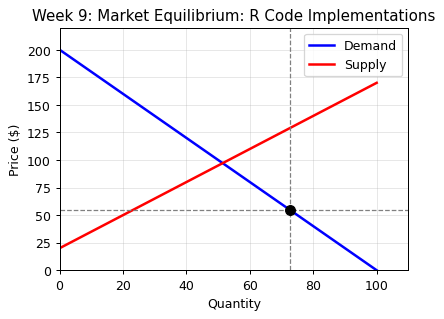

In [ ]:
# Supply & demand plot — output pre-rendered for viewer testing
P_range <- seq(0, 100, by = 0.5)
Qd <- 200 - 2 * P_range
Qs <- 20 + 1.5 * P_range
plot(Qd, P_range, type='l', col='blue', lwd=2,
     xlab='Quantity', ylab='Price', main='Supply & Demand')
lines(Qs, P_range, col='red', lwd=2)
legend('topright', c('Demand','Supply'), col=c('blue','red'), lty=1)

## Viewer Test: Empty Cell

The cell below is intentionally empty — the viewer should skip it gracefully.

## Common Patterns

**Market Equilibrium**

```r
# Solve D(p) = S(p)
# For linear: p* = (a - c)/(b + d)
# Q* = a - b*p*
```

**Tax Analysis**

```r
# p_buyer = p_seller + t
# New eq: (a - c + d*t)/(b + d)
# DWL = ½ × t × ΔQ
```

**Long-Run Equilibrium**

```r
# 1. Find min AC (where MC = AC)
# 2. p_LR = min AC
# 3. n = Q_LR / y_efficient
```

## Debugging Tips

| Error | Cause | Fix |
|-------|-------|-----|
| `Negative equilibrium price` | Demand intercept < supply intercept | Check parameter signs; c should be negative for standard upward supply |
| `Price floor not binding` | Floor set below equilibrium | Floor only binds if p_floor > p* |
| `Zero DWL from tax` | Perfectly elastic/inelastic curves | Check that both b > 0 and d > 0 |